In [42]:
import numpy as np

from scipy import stats
from scipy import signal
from scipy.ndimage import gaussian_filter1d

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from custom_hmm import PoissonHMM

import os

sns.set_context("talk")

%matplotlib widget

In [43]:
data_dir = '/mnt/home/srafilson/code/sequences/results_pyr_only_20ms/full_fit/N_251'
restarts = os.listdir(data_dir)
restarts = [f for f in restarts if f.startswith("restart_")]
likelihoods = np.zeros(len(restarts))
print(f"Found {len(restarts)} restarts")
nMissing = 0
for restart in restarts:
    data_path = f"{data_dir}/{restart}/fitted_model.npz"
    if not os.path.exists(data_path):
        nMissing += 1
        print(f"Missing data for {restart}")
        continue
    data = np.load(data_path, allow_pickle=True)
    likelihoods[restarts.index(restart)] = data["training_likelihoods"][-1]

# set zero likelihoods to -inf for better visualization
likelihoods[likelihoods == 0] = -np.inf

print(f"Missing data for {nMissing} restarts / {len(restarts)} total restarts")

# save the likelihoods to np file
np.save(f"{data_dir}/likelihoods.npy", likelihoods)

Found 410 restarts
Missing data for restart_401
Missing data for restart_6
Missing data for restart_392
Missing data for restart_395
Missing data for restart_396
Missing data for restart_386
Missing data for restart_30
Missing data for restart_17
Missing data for restart_404
Missing data for restart_407
Missing data for restart_390
Missing data for restart_406
Missing data for restart_402
Missing data for restart_409
Missing data for restart_408
Missing data for restart_405
Missing data for restart_391
Missing data for restart_398
Missing data for restart_15
Missing data for restart_389
Missing data for restart_394
Missing data for restart_14
Missing data for restart_18
Missing data for restart_393
Missing data for restart_403
Missing data for restart_11
Missing data for restart_397
Missing data for restart_399
Missing data for restart_388
Missing data for restart_387
Missing data for restart_21
Missing data for restart_16
Missing data for restart_400
Missing data for restart_8
Missing

In [44]:
# load the likelihoods from the np file
likelihoods = np.load(f"{data_dir}/likelihoods.npy")

# set zero likelihoods to -inf for better visualization
likelihoods[likelihoods == 0] = -np.inf

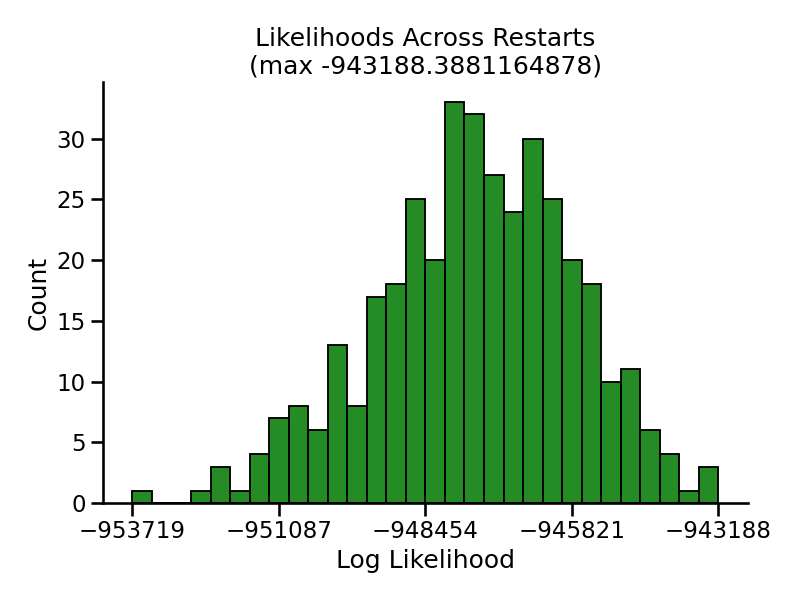

In [45]:

# plot the distribution of likelihoods across restarts
plt.figure(figsize=(8, 6))
sns.histplot(likelihoods, bins=30, color="forestgreen", alpha = 0.99)
plt.xlabel("Log Likelihood")
plt.title(f"Likelihoods Across Restarts\n(max {np.max(likelihoods)})")
# only show 5 x ticks for better visualization
min = np.min(likelihoods[likelihoods != -np.inf])
max = np.max(likelihoods)
plt.xticks(np.linspace(min, max, 5))
plt.tight_layout()
sns.despine()
plt.show()


In [46]:
sort_indices = np.argsort(likelihoods)

# get the best likelihood and corresponding parameters
best_idx = sort_indices[-1]

print(f"Best likelihood: {likelihoods[best_idx]} at restart {restarts[best_idx]}")

# get the parameters for the best fit
best_restart = restarts[best_idx]
best_data_path = f"{data_dir}/{best_restart}/fitted_model.npz"
best_data = np.load(best_data_path, allow_pickle=True)

A = best_data["A"]
B = best_data["B"]
pi = best_data["pi"]
training_llh = best_data["training_likelihoods"]

print(B.shape)


# Reorder observation columns (neurons) according to the state that emits each observation with the highest probability.
state_order = np.argsort(np.argmax(B, axis=0))
B_sorted = B[:, state_order]

# normalize so area under each column is 1
B_sorted_normalized = stats.zscore(B_sorted, axis=0)



Best likelihood: -943188.3881164878 at restart restart_335
(251, 201)


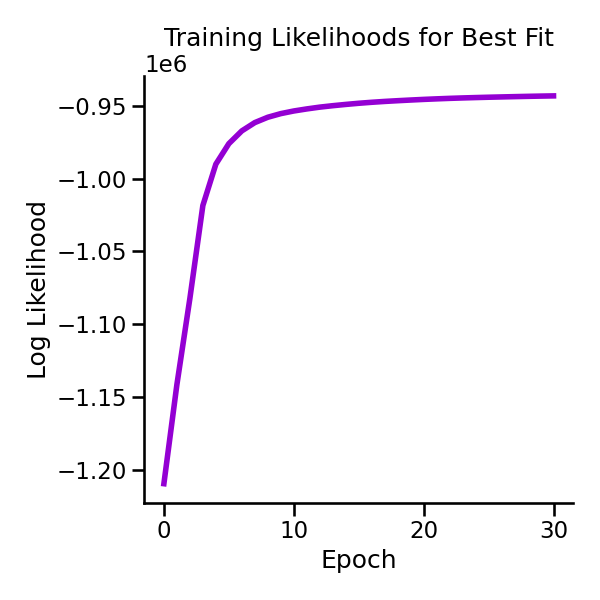

In [47]:
# plot the training likelihoods
plt.figure(figsize=(6, 6))
plt.plot(training_llh, linewidth=4, color = 'darkviolet')
plt.xlabel("Epoch")
plt.ylabel("Log Likelihood")
plt.title("Training Likelihoods for Best Fit")
plt.tight_layout()
sns.despine()
plt.show()


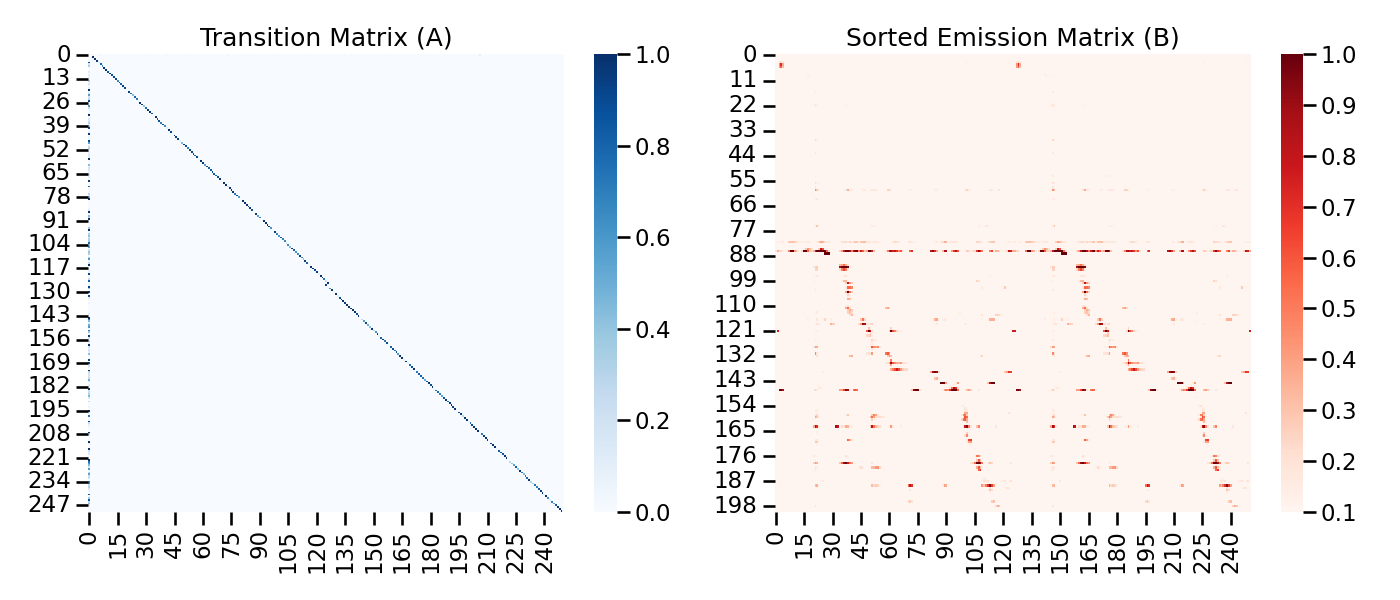

In [48]:
# plot the A and B matrices
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(A, ax=axs[0], cmap="Blues")
axs[0].set_title("Transition Matrix (A)")
sns.heatmap(B_sorted.T, ax=axs[1], cmap="Reds", vmin = 0.1, vmax = 1)
axs[1].set_title("Sorted Emission Matrix (B)")
plt.tight_layout()
plt.show()  

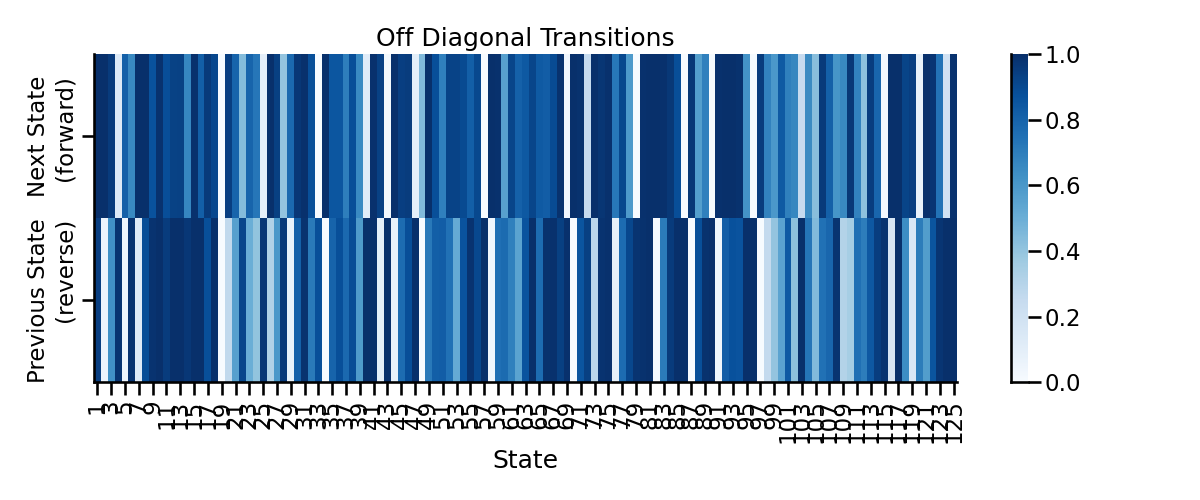

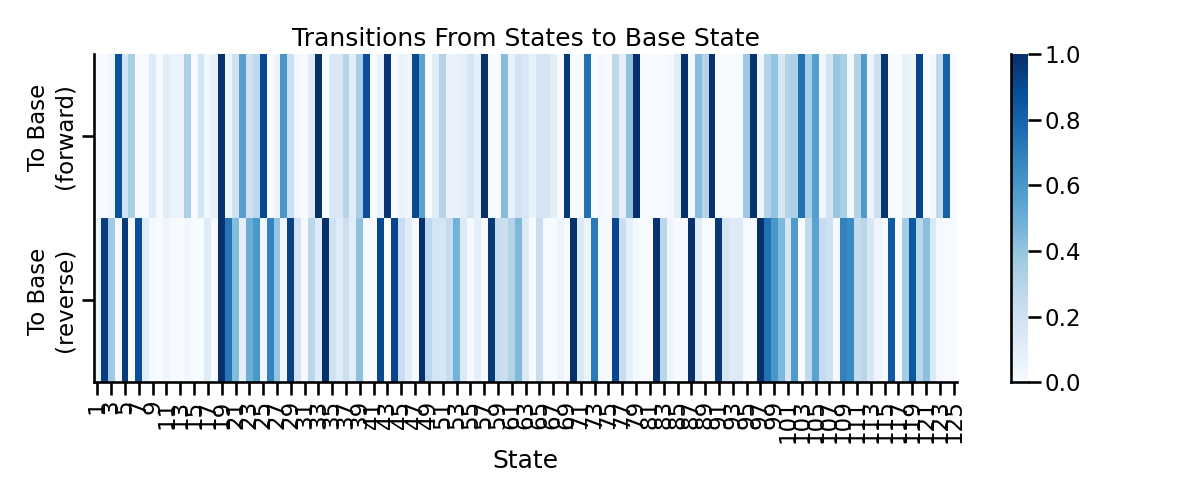

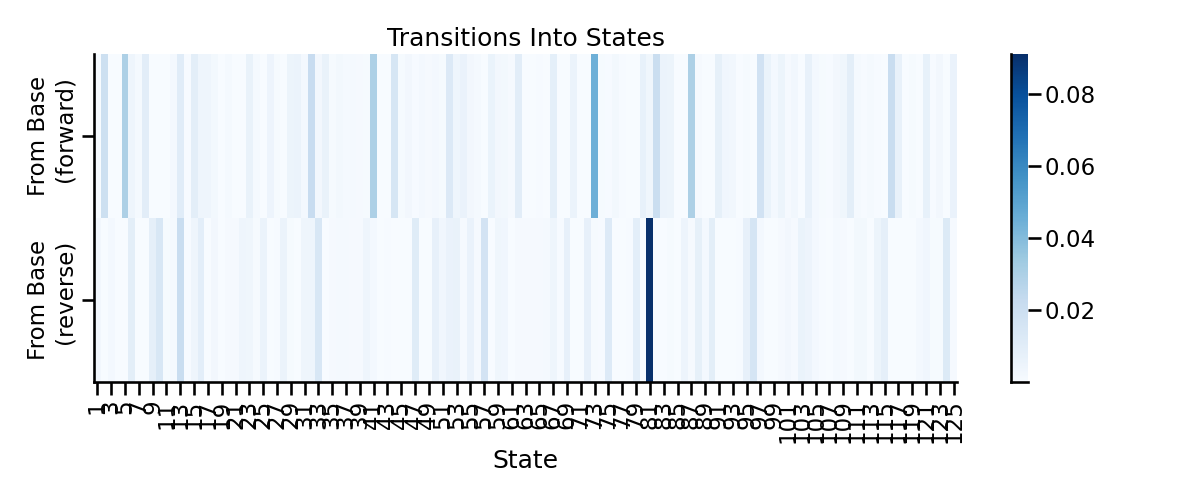

In [49]:
# plot a heatmap with 4 rows and nStates - 1 // 2 columns showing just the state transitions that are non zero
rows = 6
columns = (A.shape[0] - 1) // 2
non_zero_transitions = np.zeros((rows, columns))
for i in range(rows):
    for j in range(columns):
        if i in [0, 1]: # this is for looking at the off diagonal entries
            offset = 1 if i == 0 else columns + 1
            if i == 0:
                non_zero_transitions[i, j] = A[j + offset, j + 2]
            elif i == 1:
                non_zero_transitions[i, j] = A[j + offset, j + columns]

        elif i in [2, 3]: # this is for looking at the first column (transitions from state to the base state)
            non_zero_transitions[i, j] = A[j + 1, 0] if i == 2 else A[j + columns + 1, 0]

        elif i in [4, 5]: # this is for looking at the first row (transitions into any state from the base state)
            non_zero_transitions[i, j] = A[0, j + 1] if i == 4 else A[0, j + columns + 1]

# plot transitions from state to state (off diagonal entries)
plt.figure(figsize=(12, 5))
sns.heatmap(non_zero_transitions[:2, :], cmap="Blues")
plt.title("Off Diagonal Transitions")
plt.xlabel("State")
plt.yticks([0.5, 1.5], ["Next State\n(forward)", "Previous State\n(reverse)"])
plt.xticks(np.arange(0, columns, 2) + 0.5, np.arange(1, columns + 1, 2))
plt.tight_layout()
sns.despine()
plt.show()

# plot the transitions from the states to the base state
plt.figure(figsize=(12, 5))
sns.heatmap(non_zero_transitions[2:4, :], cmap="Blues")
plt.title("Transitions From States to Base State")
plt.xlabel("State")
plt.yticks([0.5, 1.5], ["To Base\n(forward)", "To Base\n(reverse)"])
plt.xticks(np.arange(0, columns, 2) + 0.5, np.arange(1, columns + 1, 2))
plt.tight_layout()
sns.despine()
plt.show()

# plot the transitions into the states
plt.figure(figsize=(12, 5))
sns.heatmap(non_zero_transitions[4:6, :], cmap="Blues")
plt.title("Transitions Into States")
plt.xlabel("State")
plt.yticks([0.5, 1.5], ["From Base\n(forward)", "From Base\n(reverse)"])
plt.xticks(np.arange(0, columns, 2) + 0.5, np.arange(1, columns + 1, 2))
plt.tight_layout()
sns.despine()
plt.show()




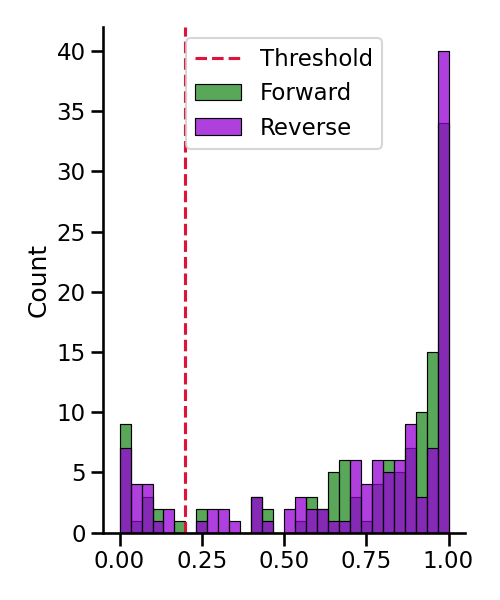

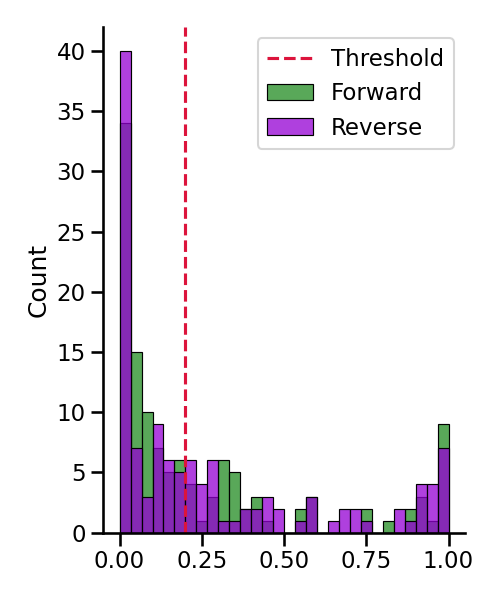

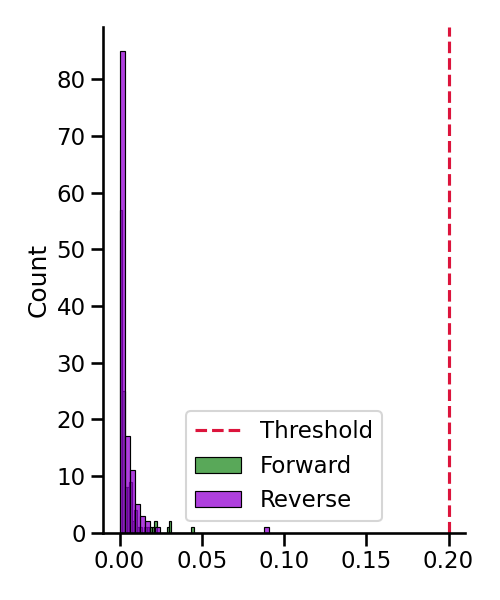

[  4  19  25  33  40  43  47  57  69  79  86  90  96 115 120 124]
[  2   5   7  19  29  34  42  44  48  58  70  76  82  87  91  97 116 119]


In [50]:
# plot the distribution of transitions probabilities for all the non-zero transitions
colors = ['forestgreen', 'darkviolet']
for i in range(3):
    plt.figure(figsize=(5, 6))
    for j in range(2):
        sns.histplot(non_zero_transitions[i * 2 + j, :], bins=30, kde=False, color = colors[j])
    
    plt.axvline(x=0.2, linestyle='--', color = 'crimson')
    plt.tight_layout()
    sns.despine()
    plt.legend([ 'Threshold', 'Forward', 'Reverse'])
    plt.show()


# get seq boundaries as where transition probs are < 0.3
seq_bounds_forward = np.where(non_zero_transitions[0, :] < 0.2)[0] + 1
seq_bounds_reverse = np.where(non_zero_transitions[1, :] < 0.2)[0] + 1

print(seq_bounds_forward)
print(seq_bounds_reverse)


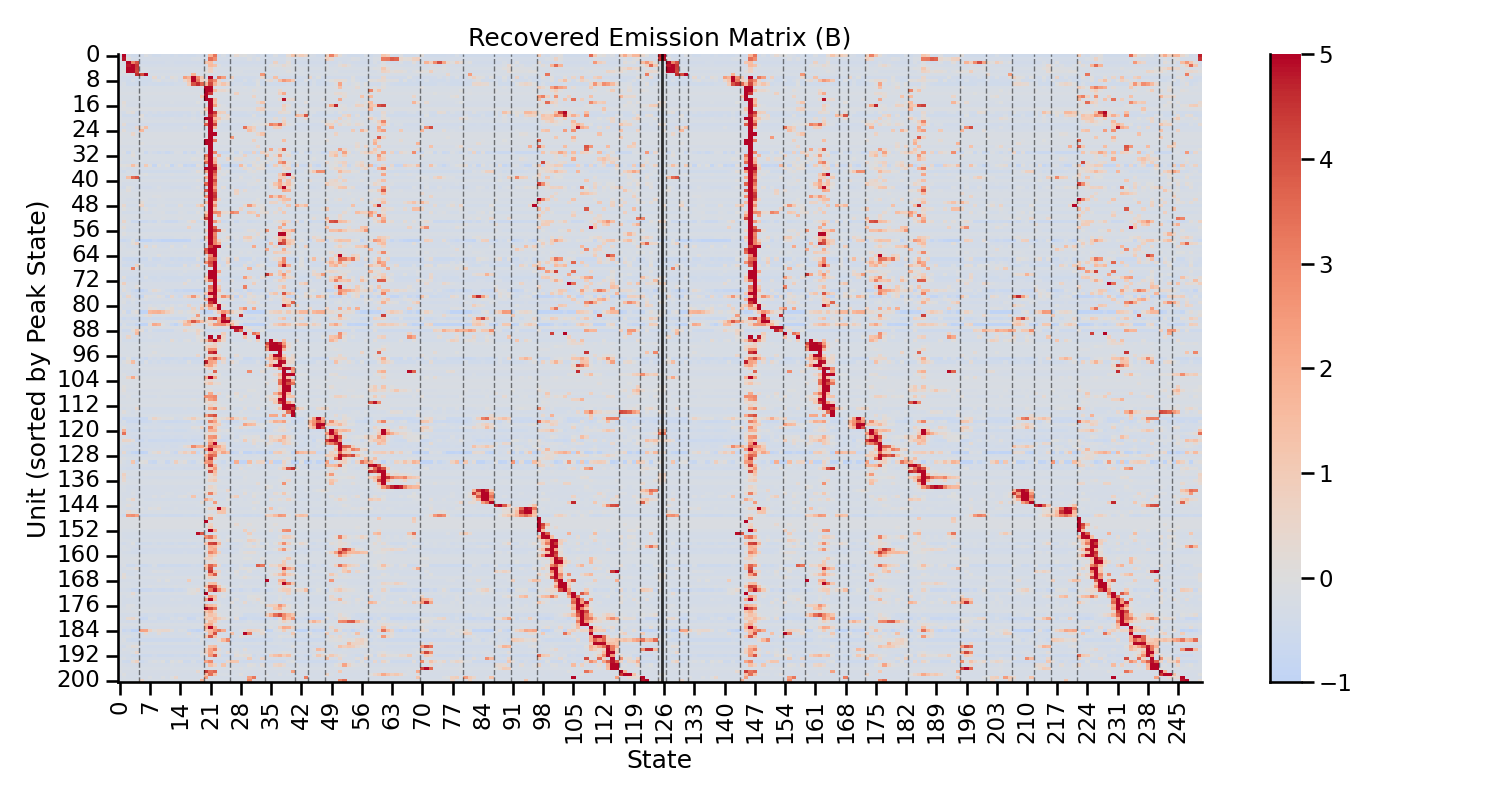

In [51]:


plt.figure(figsize=(15, 8))
sns.heatmap(B_sorted_normalized.T, cmap="coolwarm", center=0, vmin = -1, vmax = 5)

# draw verical lines at the sequence boundaries
for bound in seq_bounds_forward:
    plt.axvline(x=bound + 1, color='k', linestyle='--', linewidth=1, alpha = 0.5)

for bound in seq_bounds_reverse:
    plt.axvline(x=bound + columns, color='k', linestyle='--', linewidth=1, alpha = 0.5)

# plot vertical line between teh forward and reverse sequences
plt.axvline(x=(B.shape[0] // 2) + 1, color='k', linestyle='-', linewidth=2, alpha = 0.8)


plt.title("Recovered Emission Matrix (B)")
plt.xlabel("State")
plt.ylabel("Unit (sorted by Peak State)")
plt.tight_layout()
sns.despine()
plt.show()




(251, 201)


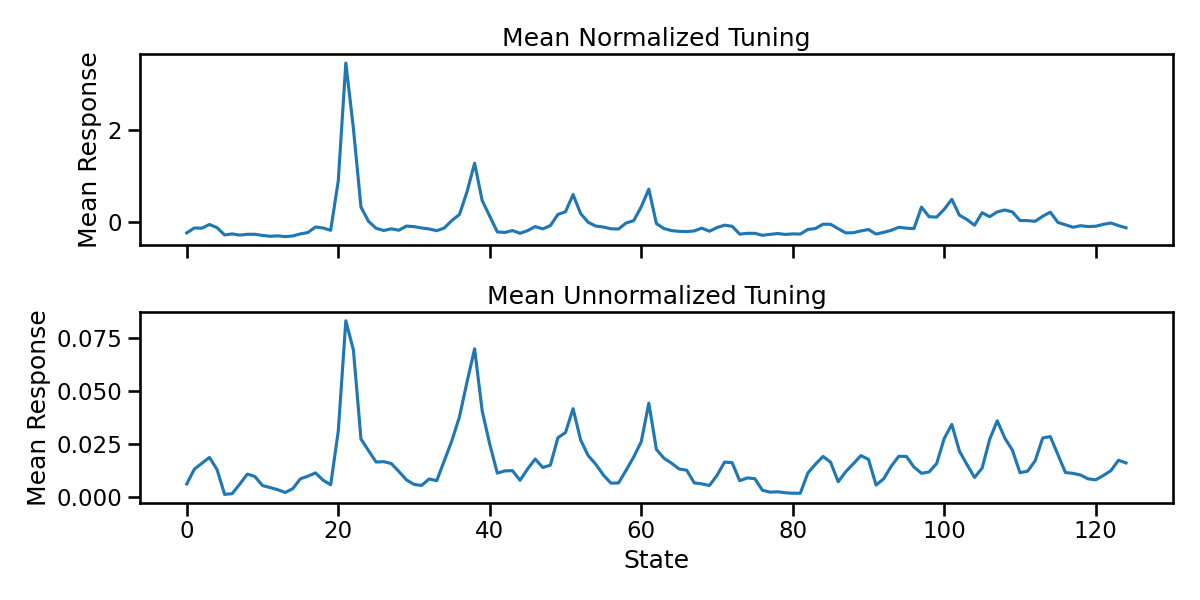

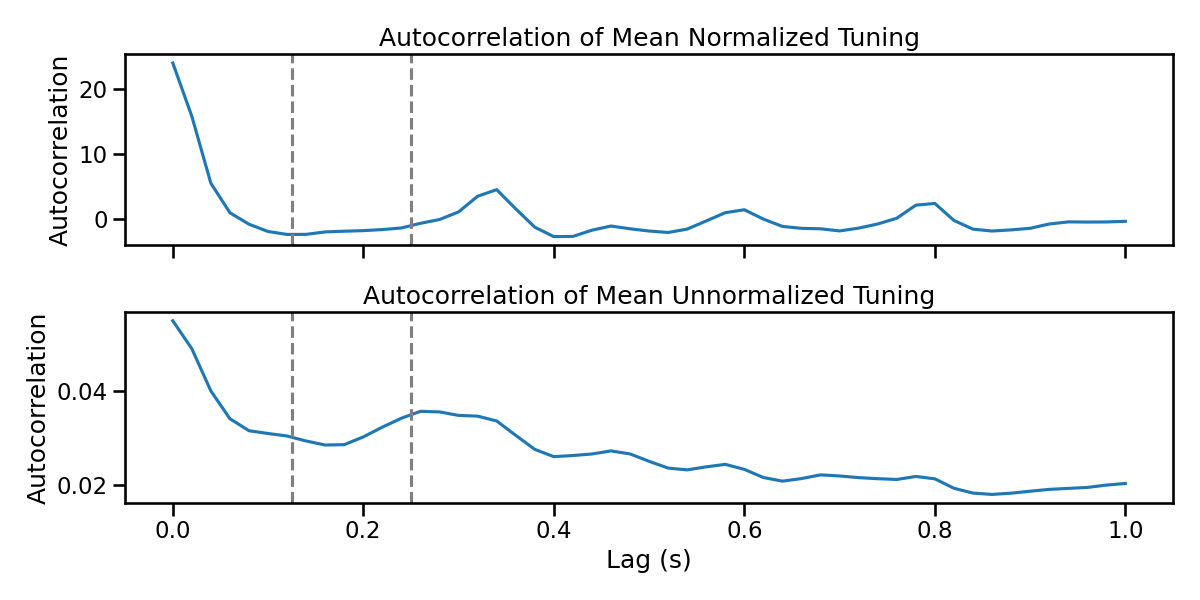

In [52]:


print(B_sorted.shape)
# get the mean tuning across neurons to the states
mean_normalized = np.mean(B_sorted_normalized[:125], axis=1)
mean_unnormalized = np.mean(B_sorted[:125], axis=1)

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axs[0].plot(mean_normalized)
axs[0].set_title("Mean Normalized Tuning")
axs[0].set_ylabel("Mean Response")

axs[1].plot(mean_unnormalized)
axs[1].set_title("Mean Unnormalized Tuning")
axs[1].set_xlabel("State")
axs[1].set_ylabel("Mean Response")

plt.tight_layout()
plt.show()

# get the autocorrelation of the mean normalized and unnormalized tuning
autocorr_normalized = signal.correlate(mean_normalized, mean_normalized, mode='full')
autocorr_unnormalized = signal.correlate(mean_unnormalized, mean_unnormalized, mode='full')
lags = signal.correlation_lags(len(mean_normalized), len(mean_normalized), mode='full')
lags = lags * 0.02  # convert lags to seconds

ind = (lags >= 0) & (lags <= 1)  # only show lags between -1 and 1 second
lags = lags[ind]
autocorr_normalized = autocorr_normalized[ind]
autocorr_unnormalized = autocorr_unnormalized[ind]

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axs[0].plot(lags, autocorr_normalized)
axs[0].set_title("Autocorrelation of Mean Normalized Tuning")
axs[0].set_ylabel("Autocorrelation")
axs[0].axvline(0.125, color='grey', linestyle='--')
axs[0].axvline(0.250, color='grey', linestyle='--')



axs[1].plot(lags, autocorr_unnormalized)
axs[1].set_title("Autocorrelation of Mean Unnormalized Tuning")
axs[1].set_xlabel("Lag (s)")
axs[1].set_ylabel("Autocorrelation")
axs[1].axvline(0.125, color='grey', linestyle='--')
axs[1].axvline(0.250, color='grey', linestyle='--')


plt.tight_layout()
plt.show()



# load in the data and run inference on the best fit parameters to get the most likely state sequence and compare to the true state sequence if available.


Tracking keys: ('timestamps', 'frameCount', 'position', 'orientation', 'errorPerMarker', 'substructnames', 'rotation_type', 'acquisition_system', 'description')
Loaded tracking data with 308232 timestamps and position shape (308232,) for x and (308232,) for y. Heading shape: (308232,)


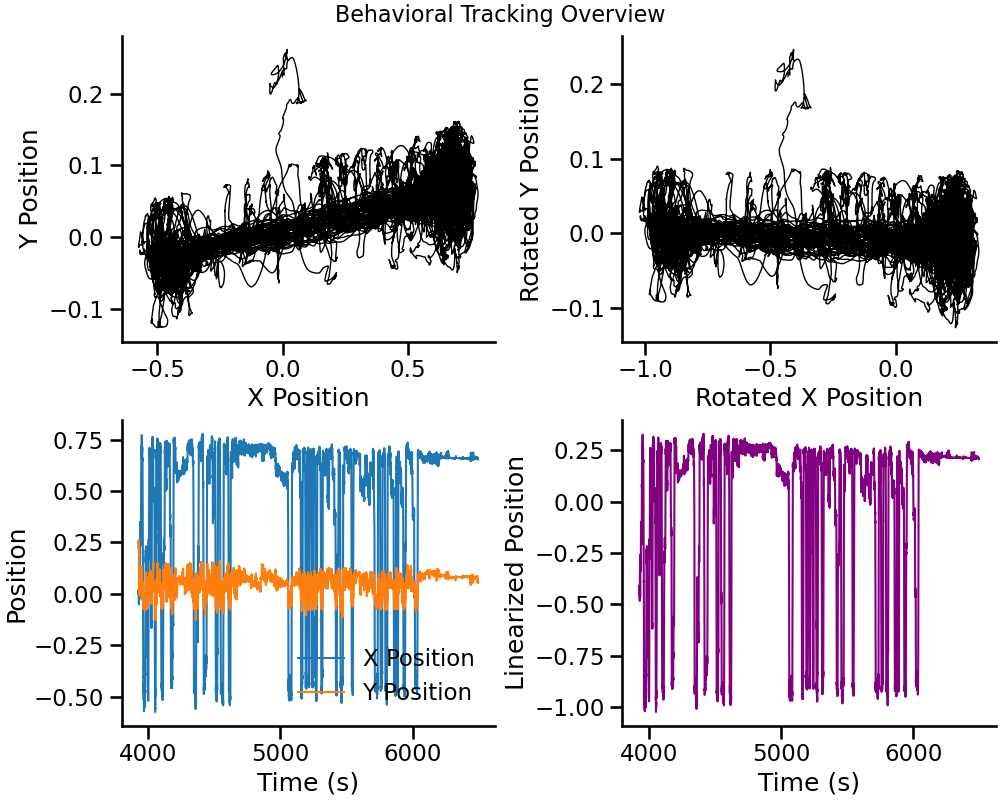

In [53]:

from scipy.io import loadmat
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d


tracking_file = '/mnt/home/srafilson/ceph/Bilat_R02_20251106/Bilat_R02_20251106_imec0.tracking.behavior.mat'
tracking = loadmat(tracking_file, squeeze_me=True)['tracking']
print("Tracking keys:", tracking.dtype.names)

tracking_timestamps = tracking['timestamps'].item() # these are timestamps in seconds which are aligned to the raw spike times

# extracting the positions
position = tracking['position'].item()
x, y = np.array(position['x'].item()), np.array(position['y'].item())

# extracting the head direction from the orientation quaternion
orientation = tracking['orientation'].item()
x_rotation = np.array(orientation['x'].item())
y_rotation = np.array(orientation['y'].item())
z_rotation = np.array(orientation['z'].item())
w = np.array(orientation['w'].item())
heading = np.arctan2(2 * (w * z_rotation + x_rotation * y_rotation), 1 - 2 * (y_rotation**2 + z_rotation**2))

print(f'Loaded tracking data with {len(tracking_timestamps)} timestamps and position shape {x.shape} for x and {y.shape} for y. Heading shape: {heading.shape}')

# do PCA to linearize the position
positions = np.vstack((x, y)).T
positions_fit_pca = positions[500:-500]
pca = PCA(n_components=1)
pca.fit(positions_fit_pca)

# project ALL positions onto the first principal component
linearized_position = pca.transform(positions).flatten()

start_behavior_time = tracking_timestamps[0]
end_behavior_time = tracking_timestamps[-1]





fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

# --- Top: XY trajectory ---
axs[0,0].plot(x, y, color="black", linewidth=1)
axs[0,0].set_xlabel("X Position")
axs[0,0].set_ylabel("Y Position")



# --- Bottom: Position over time ---
axs[1,0].plot(tracking_timestamps, x, label="X Position", linewidth=1.5)
axs[1,0].plot(tracking_timestamps, y, label="Y Position", linewidth=1.5)
axs[1,0].set_xlabel("Time (s)")
axs[1,0].set_ylabel("Position")
axs[1,0].legend(frameon=False)

# --- Optional: linearized position over time
axs[1,1].plot(tracking_timestamps, linearized_position, color="purple", linewidth=1.5)
axs[1,1].set_xlabel("Time (s)")
axs[1,1].set_ylabel("Linearized Position")


# rotate the XY trajectory by the angle of the first principal component for better visualization
angle = np.arctan2(pca.components_[0, 1], pca.components_[0, 0])

rotation_matrix = np.array([
    [np.cos(-angle), -np.sin(-angle)],
    [np.sin(-angle),  np.cos(-angle)]
])

rotated_positions = (positions - positions.mean(axis=0)) @ rotation_matrix.T
axs[0,1].plot(rotated_positions[:,0], rotated_positions[:,1], color="black", linewidth=1)
axs[0,1].set_xlabel("Rotated X Position")
axs[0,1].set_ylabel("Rotated Y Position")



sns.despine()
fig.suptitle("Behavioral Tracking Overview", fontsize=16)
plt.show()



In [54]:
# Load the spike counts
data_path = '/mnt/home/srafilson/code/sequences/data/maze_clipped_spike_counts_pyr_only_Bilat_R02_20251106.npz'
data = np.load(data_path, allow_pickle=True)

print(data.files)

# get the observations and true states from the data
observations = data["observations"]
print(f"Observations shape: {observations.shape}")
if "states" in data:
    true_states = data["states"]
else:
    true_states = None

if "time_bins" in data:
    time_bins = data["time_bins"]
else:
    time_bins = None



['observations', 'time_bins']
Observations shape: (130600, 201)


In [55]:
# resample the linearized position so that each position corresponds to a time bin in the observations
if time_bins is not None:
    # get the start and end time of the observations
    start_time = time_bins[0]
    end_time = time_bins[-1]

    # resample the linearized position to match the number of time bins in the observations
    linearized_position_resampled = np.interp(time_bins, tracking_timestamps, linearized_position)
    
    # resample the heading to match the number of time bins in the observations
    heading_resampled = np.interp(time_bins, tracking_timestamps, heading)

    print(f"Resampled linearized position to match observations: {linearized_position_resampled.shape} vs {observations.shape[0]} time bins.")
    print(f"Resampled heading to match observations: {heading_resampled.shape} vs {observations.shape[0]} time bins.")

    # bin the linearized position into discrete states
    n_bins = 50
    linearized_position_binned = np.digitize(linearized_position_resampled, bins=np.linspace(np.min(linearized_position_resampled), np.max(linearized_position_resampled), n_bins))
    heading_binned = np.digitize(heading_resampled, bins=np.linspace(np.min(heading_resampled), np.max(heading_resampled), n_bins))
else:
    linearized_position_resampled = None
    linearized_position_binned = None
    heading_resampled = None
    heading_binned = None
    print("No time_bins found in the data. Skipping resampling of linearized position and heading.")


velocity = gaussian_filter1d(np.gradient(linearized_position_resampled, time_bins), sigma=5) * 100 #convert to cm/s
speed = np.abs(velocity)
running_direction = np.sign(velocity)

heading_velocity = gaussian_filter1d(np.gradient(heading_resampled, time_bins), sigma=3)
heading_speed = np.abs(heading_velocity)
heading_sweep_direction = np.sign(heading_velocity)

Resampled linearized position to match observations: (130600,) vs 130600 time bins.
Resampled heading to match observations: (130600,) vs 130600 time bins.


## Initialize the Hidden Markov Model and find the hidden state sequence

In [56]:
# Initialize the Poisson HMM with the given parameters
model = PoissonHMM(
    A=A,
    B=B,
    pi=pi
)

# Set the observations for the model
model.set_observations(observations)

# Run the Viterbi algorithm to find the most likely sequence of hidden states
states = model.viterbi()


## Plot the HMM state sequence, spike raster, and behavior

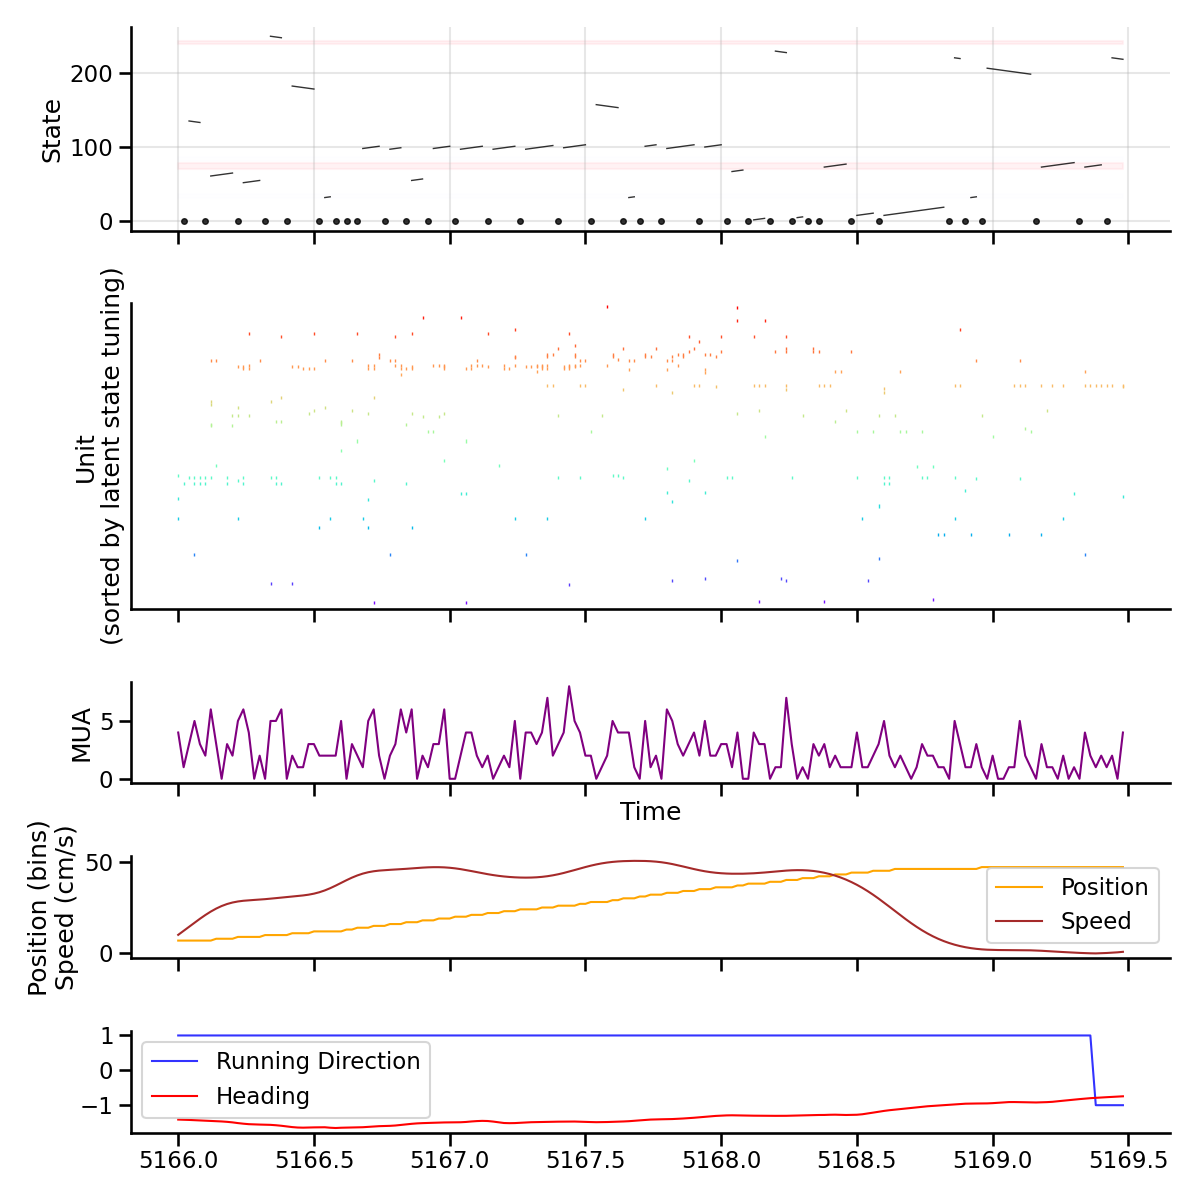

In [57]:
start_time_s = 5166
end_time_s = 5169.5

start_time = np.searchsorted(time_bins, start_time_s)
end_time = np.searchsorted(time_bins, end_time_s)

t = time_bins[start_time:end_time]

# MUA should sum across units for each time bin
mua = np.sum(observations, axis=1)



obs_sorted = observations[start_time:end_time][:, state_order]

fig, axs = plt.subplots(
    5, 1,
    figsize=(12, 12),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 3, 1, 1, 1]}
)

if True:

    # fill between states 10 and 20
    axs[0].fill_between(
        t,
        71,
        78,
        color="pink",
        alpha=0.2
    )

    # fill between states 10 and 20
    axs[0].fill_between(
        t,
        239,
        243,
        color="pink",
        alpha=0.2
    )


    # fill between states 10 and 20
    axs[0].fill_between(
        t,
        92,
        98,
        color="green",
        alpha=0.001
    )

    # fill between states 10 and 20
    axs[0].fill_between(
        t,
        217,
        223,
        color="green",
        alpha=0.001
    )


    # fill between states 10 and 20
    axs[0].fill_between(
        t,
        31,
        37,
        color="blue",
        alpha=0.005
    )

    # fill between states 10 and 20
    axs[0].fill_between(
        t,
        81,
        87,
        color="blue",
        alpha=0.005
    )








# inferred state sequence, avoiding lines through base state
state_seq = states[start_time:end_time]
base_state = 0


axs[0].set_ylabel("State")
axs[0].grid(alpha=0.3)

# plot non-base states, broken wherever base state occurs
non_base = np.where(state_seq != base_state, state_seq, np.nan)

axs[0].plot(
    t,
    non_base,
    linewidth=1,
    alpha=0.8,
    color="black"
)

# plot base-state runs separately
is_base = state_seq == base_state

# find contiguous base-state runs
base_idx = np.where(is_base)[0]

if len(base_idx) > 0:
    split_points = np.where(np.diff(base_idx) > 1)[0] + 1
    base_runs = np.split(base_idx, split_points)

    for run in base_runs:
        if len(run) == 1:
            axs[0].plot(
                t[run],
                state_seq[run],
                marker="o",
                linestyle="None",
                color="k",
                markersize=4,
                alpha=0.8
            )
        else:
            axs[0].plot(
                t[run],
                state_seq[run],
                linewidth=2,
                color="k",
                alpha=0.8
            )



# spike raster: one tick for any count >= 1
n_units = obs_sorted.shape[1]

spike_times_by_unit = [
    t[obs_sorted[:, unit_idx] >= 1]
    for unit_idx in range(n_units)
]

colors = plt.cm.rainbow(np.linspace(0, 1, n_units))

axs[1].eventplot(
    spike_times_by_unit,
    orientation="horizontal",
    colors=colors,
    lineoffsets=np.arange(n_units),
    linelengths=2,
    linewidths=1
)


axs[1].set_ylabel("Unit\n(sorted by latent state tuning)")
axs[1].set_ylim(-1, n_units)
axs[1].set_yticks([])

# MUA
axs[2].plot(
    t,
    mua[start_time:end_time],
    label="MUA",
    color="purple",
    linewidth=1.5
)

axs[2].set_xlabel("Time")
axs[2].set_ylabel("MUA")



axs[3].plot(
    t,
    linearized_position_binned[start_time:end_time],
    label="Position",
    color="orange",
    linewidth=1.5,
)

axs[3].plot(
    t,
    speed[start_time:end_time],
    label="Speed",
    color="brown",
    linewidth=1.5,
)

axs[3].set_ylabel("Position (bins)\nSpeed (cm/s)")
axs[3].legend()

axs[4].plot(
    t,
    running_direction[start_time:end_time],
    label="Running Direction",
    color="blue",
    linewidth=1.5,
    alpha=0.8
)

# plot the heading
axs[4].plot(
    t,
    heading[start_time:end_time],
    label="Heading",
    color="red",
    linewidth=1.5,

)
axs[4].legend()




sns.despine()
plt.tight_layout()
plt.show()

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

alpha = 0.05

# observations: shape (n_time_bins, n_neurons)
# B: shape (n_states, n_neurons)
# states: shape (n_time_bins,)

# Expected rate for every time bin and neuron
expected_rates = B[states]  # shape: (time, neurons)

# Directional Poisson tail probabilities
#
# P(X <= observed): unusually low counts
p_low = poisson.cdf(observations, expected_rates)

# P(X >= observed): unusually high counts
# sf(k - 1) = P(X >= k)
p_high = poisson.sf(observations - 1, expected_rates)

unexpected_low = p_low < alpha
unexpected_high = p_high < alpha

In [59]:


obs_plot = observations[:, state_order]
low_plot = unexpected_low[:, state_order]
high_plot = unexpected_high[:, state_order]

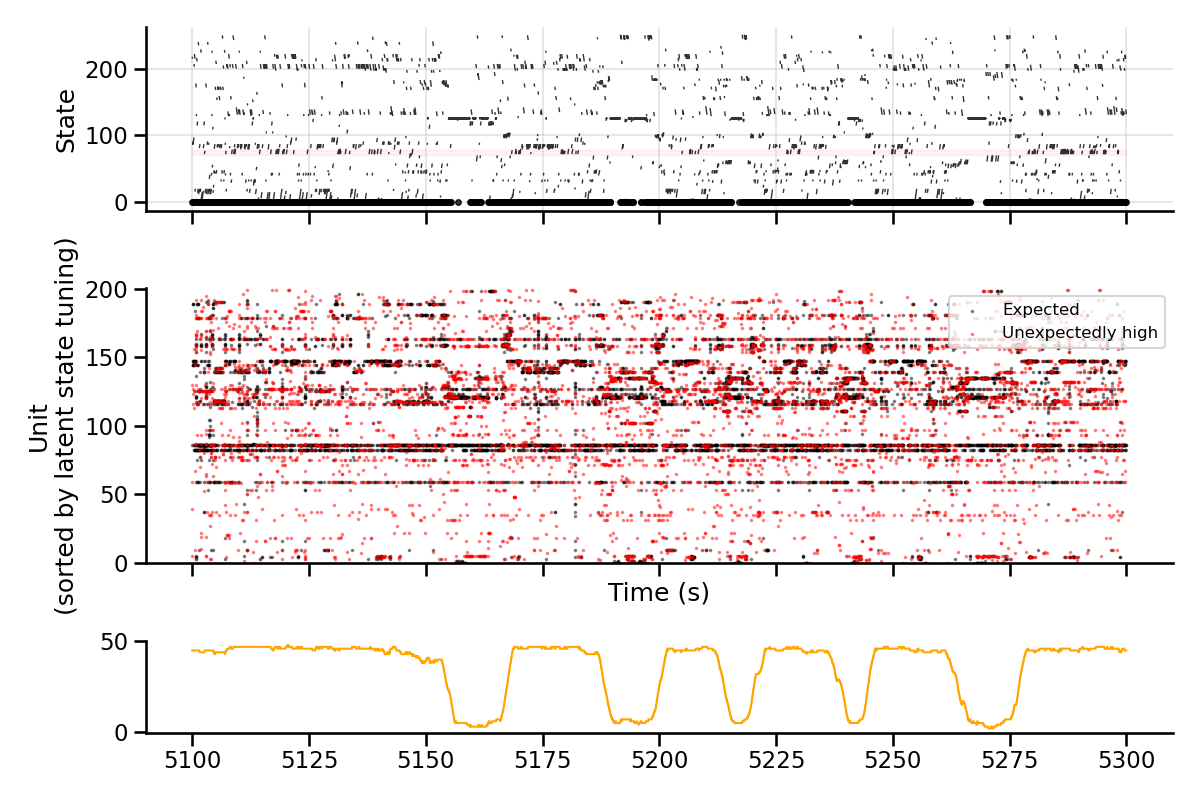

In [61]:
start_time_s = 5100
end_time_s = 5300

start_idx = np.searchsorted(time_bins, start_time_s)
end_idx = np.searchsorted(time_bins, end_time_s)

t_plot = time_bins[start_idx:end_idx]

# sort neurons by preferred (peak-emission) state, same as the earlier rasters
obs_plot = observations[start_idx:end_idx][:, state_order]
low_plot = unexpected_low[start_idx:end_idx][:, state_order]
high_plot = unexpected_high[start_idx:end_idx][:, state_order]

state_seq = states[start_idx:end_idx]
n_units = obs_plot.shape[1]

fig, axs = plt.subplots(
    3,
    1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 3, 1]},
)

# ---------------------------------------------------------
# State sequence
# ---------------------------------------------------------
base_state = 0

axs[0].set_ylabel("State")
axs[0].grid(alpha=0.3)

# Break the line wherever the base state occurs
non_base = np.where(state_seq != base_state, state_seq, np.nan)

# fill between states 10 and 20
axs[0].fill_between(
    t_plot,
    71,
    78,
    color="pink",
    alpha=0.2
)

axs[0].plot(
    t_plot,
    non_base,
    linewidth=1,
    alpha=0.8,
    color="black",
)

# Plot contiguous base-state runs separately
base_idx = np.flatnonzero(state_seq == base_state)

if base_idx.size:
    split_points = np.flatnonzero(np.diff(base_idx) > 1) + 1
    base_runs = np.split(base_idx, split_points)

    for run in base_runs:
        if run.size == 1:
            axs[0].plot(
                t_plot[run],
                state_seq[run],
                marker="o",
                linestyle="none",
                color="black",
                markersize=4,
                alpha=0.8,
            )
        else:
            axs[0].plot(
                t_plot[run],
                state_seq[run],
                linewidth=2,
                color="black",
                alpha=0.8,
            )

# ---------------------------------------------------------
# Raster
# ---------------------------------------------------------

# Coordinates for bins containing at least one spike
spike_t, spike_neuron = np.nonzero(obs_plot >= 1)

# Classify only observed spike bins
spike_is_high = high_plot[spike_t, spike_neuron]
spike_is_low = low_plot[spike_t, spike_neuron]
spike_is_normal = ~(spike_is_high | spike_is_low)

# Normal observed spikes: black
axs[1].scatter(
    t_plot[spike_t[spike_is_normal]],
    spike_neuron[spike_is_normal],
    marker=".",
    s=10,
    color="black",
    linewidths=1,
    label="Expected",
    alpha=0.4,
)

# Unexpectedly high observed spike counts: blue
axs[1].scatter(
    t_plot[spike_t[spike_is_high]],
    spike_neuron[spike_is_high],
    marker=".",
    s=10,
    color="red",
    linewidths=1,
    label=f"Unexpectedly high",
    alpha=0.4,
)

# This category is possible when an observed count is below expectation
# but is still at least one.
axs[1].scatter(
    t_plot[spike_t[spike_is_low]],
    spike_neuron[spike_is_low],
    marker=".",
    s=10,
    color="blue",
    linewidths=1,
    alpha=0.4,
)

# Unexpectedly low zero-count bins cannot appear as ordinary raster ticks.
# Show them as small red horizontal markers.
missing_t, missing_neuron = np.nonzero(
    (obs_plot == 0) & low_plot
)

axs[1].scatter(
    t_plot[missing_t],
    missing_neuron,
    marker="_",
    s=18,
    color="blue",
    linewidths=0.8,
    alpha=0.7,
)

axs[1].set_ylim(-0.5, n_units - 0.5)
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Unit\n(sorted by latent state tuning)")
axs[1].legend(
    loc="upper right",
    fontsize=12,
)

# plot the position

axs[2].plot(
    t_plot,
    linearized_position_binned[start_idx:end_idx],
    label="Position",
    color="orange",
    linewidth=1.5,
)

sns.despine()

plt.tight_layout()
plt.show()

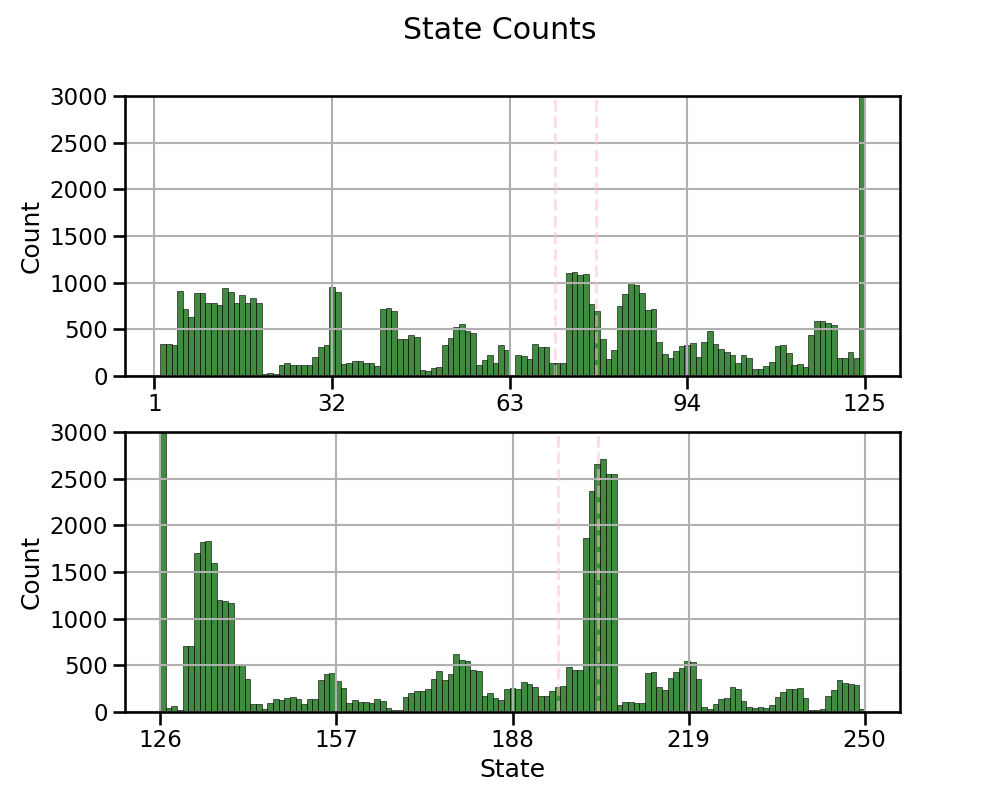

In [62]:
# get the counts for how how often in each state
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
sns.histplot(states[(states != 0) & (states <= 125)], bins = 125,ax=axs[0], color = 'darkgreen')
axs[0].set_ylabel('Count')
axs[0].set_xticks(np.linspace(1, 125, 5))
axs[0].axvline(x=71, color='pink', alpha=0.5, linestyle='--')
axs[0].axvline(x=78, color='pink', alpha=0.5, linestyle='--')
axs[0].set_ylim(0,3000)
axs[0].grid(True)

sns.histplot(states[states > 125], bins = 125, ax=axs[1], color = 'darkgreen')
axs[1].set_xlabel('State')
axs[1].set_ylabel('Count')
axs[1].set_xticks(np.linspace(126, 250, 5))
axs[1].axvline(x=196, color='pink', alpha=0.5, linestyle='--')
axs[1].axvline(x=203, color='pink', alpha=0.5, linestyle='--')
axs[1].set_ylim(0,3000)
axs[1].grid(True)



plt.suptitle('State Counts')

plt.show()

# Place Field/Tuning Curve Analysis

/mnt/sw/nix/store/7kfpfhj104s5hynnhr5jzsrm25p4vwla-python-3.11.11-view/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


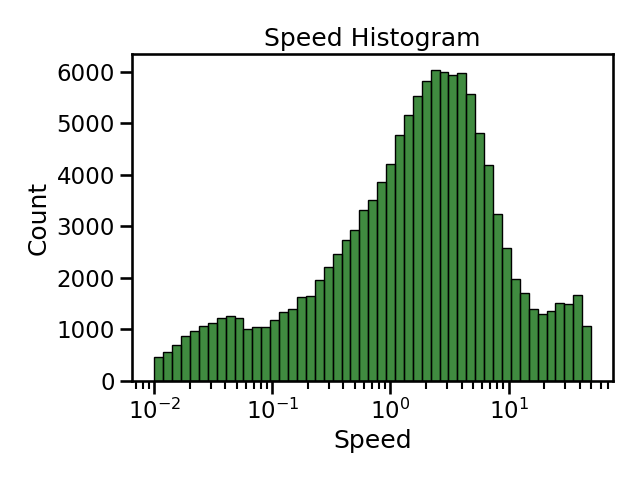

/mnt/sw/nix/store/7kfpfhj104s5hynnhr5jzsrm25p4vwla-python-3.11.11-view/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


In [63]:
# make place fields
place_fields = np.zeros((3, A.shape[0], linearized_position_binned.max() + 1))

for state in range(A.shape[0]):
    for direction in [-1, 0, 1]:

        # set the speed criterion based on the direction
        if direction == 0:
            speed_criterion = speed < 5
            direction_criterion = True
        else:
            speed_criterion = speed >= 5
            direction_criterion = (running_direction == direction)


        # get the time bins where the state is active and the direction matches
        state_active = (states == state) & direction_criterion & speed_criterion

        # check there are at least 100 time bins for this state and direction
        if np.sum(state_active) < 100:
            place_fields[0 if direction == -1 else 1 if direction == 0 else 2, state] = 0
            continue

        # get the linearized position bins for those time bins
        position_bins = linearized_position_binned[state_active]

        # compute the histogram of position bins for this state and direction
        place_fields[0 if direction == -1 else 1 if direction == 0 else 2, state], _ = np.histogram(position_bins, bins=np.arange(linearized_position_binned.max() + 2), density=True)

# smooth the directional place fields with a Gaussian filter
for direction in range(3):
    place_fields[direction] = gaussian_filter1d(place_fields[direction], sigma=1, axis=1)


# make head direction tuning curve from heading
head_direction_tuning = np.zeros((A.shape[0], heading_binned.max() + 1))

for state in range(A.shape[0]):
    # get the time bins where the state is active
    state_active = states == state

    # get the heading bins for those time bins
    heading_bins = heading_binned[state_active]

    # compute the histogram of heading bins for this state
    head_direction_tuning[state], _ = np.histogram(heading_bins, bins=np.arange(heading_binned.max() + 2), density=True)

# smooth the head direction tuning curves with a Gaussian filter
head_direction_tuning_smoothed = gaussian_filter1d(head_direction_tuning, sigma=1, axis=1)



# plto speed histogram
plt.figure()
#black edges
sns.histplot(speed, bins = np.logspace(np.log10(0.01), np.log10(50), 50), color = 'darkgreen', edgecolor='black', linewidth=1)
plt.xscale('log')
plt.xlabel('Speed')
plt.ylabel('Count')
plt.xscale('log')
plt.title('Speed Histogram')
plt.tight_layout()
plt.show()

# running speed tuning curves
nSpeedBins = 50
speed_bins = np.logspace(np.log10(0.01), np.log10(50), nSpeedBins + 1)

speed_binned = np.digitize(speed, speed_bins) - 1
speed_tuning = np.zeros((A.shape[0], nSpeedBins))
for state in range(A.shape[0]):
    # get the time bins where the state is active
    state_active = states == state

    # get the speed bins for those time bins
    speed_bins_for_state = speed_binned[state_active]

    # compute the histogram of speed bins for this state
    speed_tuning[state], _ = np.histogram(speed_bins_for_state, bins=np.arange(nSpeedBins + 1), density=True)

speed_tuning_smoothed = gaussian_filter1d(speed_tuning, sigma=1, axis=1)

    
        


        

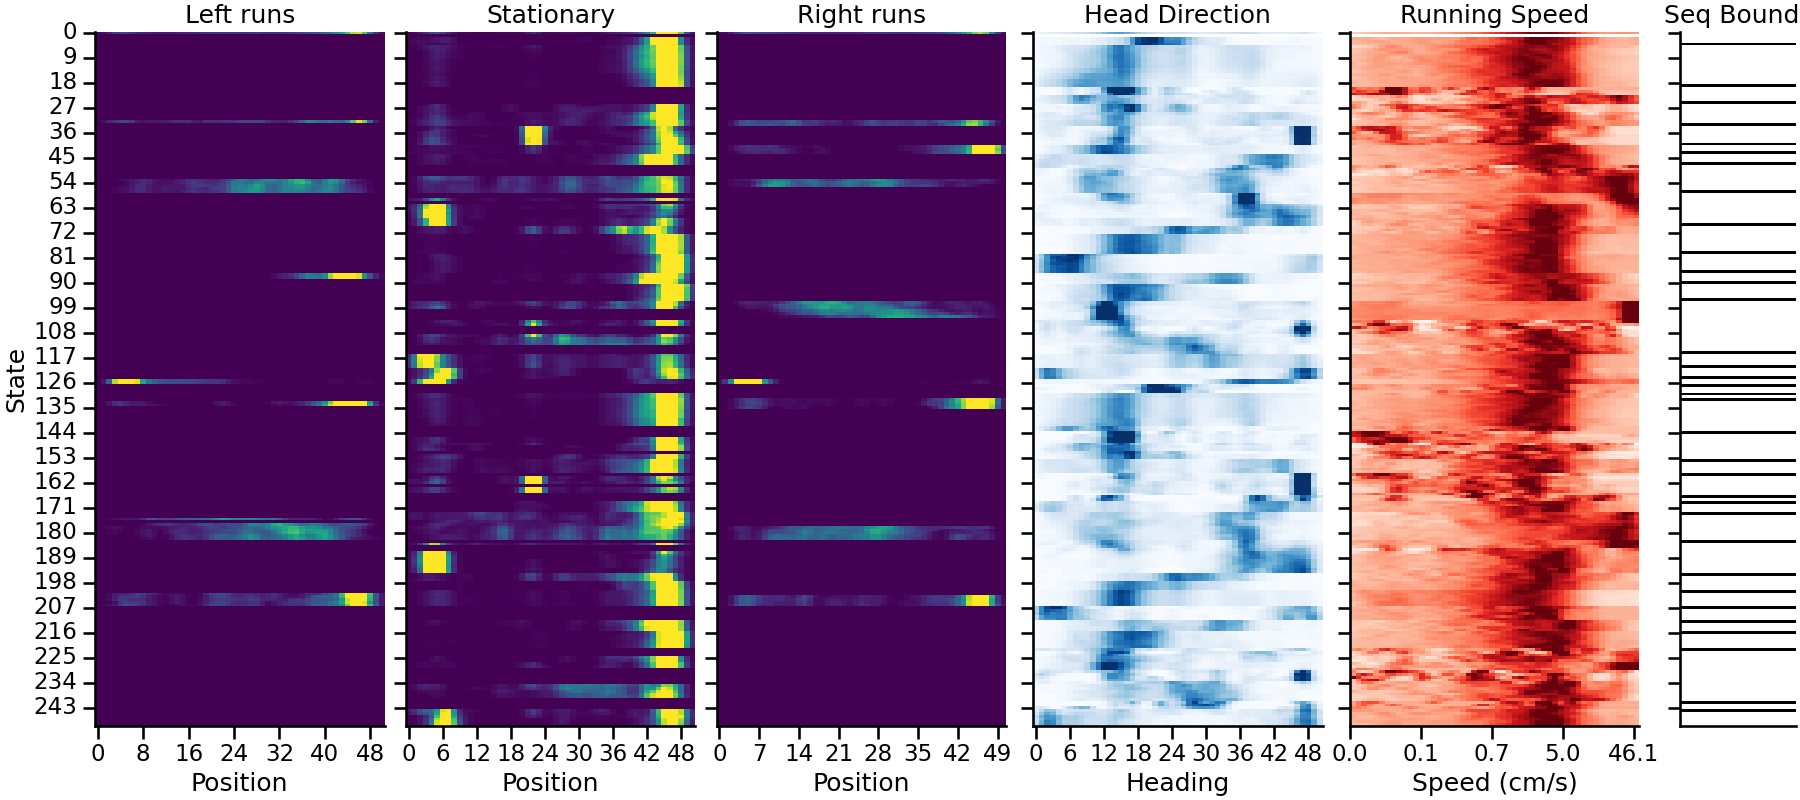

In [64]:

# plot the directional place fields as heatmaps
fig, axs = plt.subplots(1, 6, figsize=(18, 8), constrained_layout=True, sharey=True, gridspec_kw={"width_ratios": [1, 1, 1, 1, 1, 0.4]})

# plot the directional place fields
sns.heatmap(place_fields[0], ax=axs[0], cmap="viridis", cbar_kws={'label': 'Probability Mass'}, vmin=0, vmax=0.09)
axs[0].set_title("Left runs")
axs[0].set_xlabel("Position")
axs[0].set_ylabel("State")


# remove colorbar for the first heatmap to avoid redundancy
axs[0].collections[0].colorbar.remove()



# non directional
sns.heatmap(place_fields[1], ax=axs[1], cmap='viridis', cbar_kws={'label': 'Probability Mass'}, vmin=0, vmax=0.09)
axs[1].collections[0].colorbar.remove()
axs[1].set_title("Stationary")
axs[1].set_xlabel("Position")


sns.heatmap(place_fields[2], ax=axs[2], cmap="viridis", cbar_kws={'label': 'Probability Mass'}, vmin=0, vmax=0.09)
axs[2].collections[0].colorbar.remove()
axs[2].set_title("Right runs")
axs[2].set_xlabel("Position")


# heading
sns.heatmap(head_direction_tuning_smoothed, ax=axs[3], cmap="Blues", cbar_kws={'label': 'Probability Mass'}, vmin=0, vmax=0.09)
axs[3].collections[0].colorbar.remove()
axs[3].set_title("Head Direction")
axs[3].set_xlabel("Heading")

# running speed tuning curves
sns.heatmap(stats.zscore(speed_tuning_smoothed, axis=1), ax=axs[4], cmap="Reds", cbar_kws={'label': 'Probability'}, vmin=-2, vmax=2)
axs[4].collections[0].colorbar.remove()
axs[4].set_title("Running Speed")
axs[4].set_xlabel("Speed (cm/s)")

# plot x axis as speed (cm/s) for the running speed tuning curves
bin_centers = (speed_bins[:-1] + speed_bins[1:]) / 2
axs[4].set_xticks(np.linspace(0, len(bin_centers) - 1, 5))
axs[4].set_xticklabels([f"{bin_centers[int(i)]:.1f}" for i in np.linspace(0, len(bin_centers) - 1, 5)])

# plot forward and reverse sequence boundaries as heatmap

# get seq boundaries as where transition probs are < 0.3
seq_bounds_heatmap = np.zeros((250, 2))
seq_bounds_heatmap[seq_bounds_forward, :] = 1
seq_bounds_heatmap[seq_bounds_reverse + 125, :] = 1

sns.heatmap(seq_bounds_heatmap, ax=axs[5], cmap="Greys", cbar_kws={'label': 'Sequence Boundaries'}, vmin=0, vmax=1)
axs[5].collections[0].colorbar.remove()
axs[5].set_title("Seq Bounds")
axs[5].set_xlabel("")
axs[5].set_xticks([])


sns.despine()
plt.show()




# Anatomical Propogation Analysis

In [36]:
# loading the data dicts to get the anatomical positions of the units (shank and probe numbers)
data_dict_path = '/mnt/home/srafilson/code/sequences/data/data_dicts_all_neurons.npz'
data_dict = np.load(data_dict_path, allow_pickle=True)

PROBES = [2, 3]                                                                 # list of probe numbers to include in the analysis
probe_shank_order = [                                                           
    (2,4), (2,3), (2,2), (2,1), (3,1), (3,2), (3,3), (3,4)                      # this list is sorted by probe and shank number from anterior to posterior (septal-> temporal)
]                                                                               # so that we can sort the units in the spike count matrix according to anotmical position

# concatenate spike count matrices and time bins across probes for the decoding analysis keeping on the valid units
all_spike_counts = []
all_time_bins = []
shank_IDs = []
probe_IDs = []
for probe in PROBES:
    if f'probe{probe}' in data_dict:
        probe_data = data_dict[f'probe{probe}'].item()
        if 'spike_count_matrix' in probe_data and 'time_bins' in probe_data:
            valid_units = probe_data['valid_units']
            all_spike_counts.append(probe_data['spike_count_matrix'][valid_units, :]) # only keep the valid units for the decoding analysis
            all_time_bins.append(probe_data['time_bins'])
            # get the shank IDs for the valid units
            shank_IDs.append(probe_data['shankID'][valid_units])
            probe_IDs.append(np.full(np.sum(valid_units), probe))
        else:
            print(f"Probe {probe}: Missing spike count matrix or time bins for concatenation.")
    else:
        print(f"Probe {probe}: Missing data in the loaded dictionary.")

spike_count_matrix = np.concatenate(all_spike_counts, axis=0) if all_spike_counts else np.array([]) # shape: (total_units_across_probes, n_time_bins)
time_bins = all_time_bins[0] if all_time_bins else np.array([])
shank_IDs = np.concatenate(shank_IDs, axis=0) if shank_IDs else np.array([])
probe_IDs = np.concatenate(probe_IDs, axis=0) if probe_IDs else np.array([])



# determine the anatomical order of units based on their probe and shank IDs
anatomical_order = []
for unit_idx in range(spike_count_matrix.shape[0]):
    probe = probe_IDs[unit_idx]
    shank = shank_IDs[unit_idx]
    anatomical_order.append(probe_shank_order.index((probe, shank)))
anatomical_order = np.array(anatomical_order)
n_anatomical_positions = np.unique(anatomical_order).size

# Reorder observation columns (neurons) according to the state that emits each observation with the highest probability.
state_order = np.argsort(np.argmax(B, axis=0))
B_sorted = B[:, state_order]

# normalize so area under each column is 1
B_sorted_normalized = stats.zscore(B_sorted, axis=0)

# sort the anatomical order of neurons
anatomical_sort_order = np.argsort(anatomical_order)


# average all the columns of B with the same anatomical_order value
B_anatomical_averaged = np.zeros((B.shape[0], len(np.unique(anatomical_order))))
for i, val in enumerate(np.unique(anatomical_order)):
    B_anatomical_averaged[:, i] = B[:, anatomical_order == val].mean(axis=1)

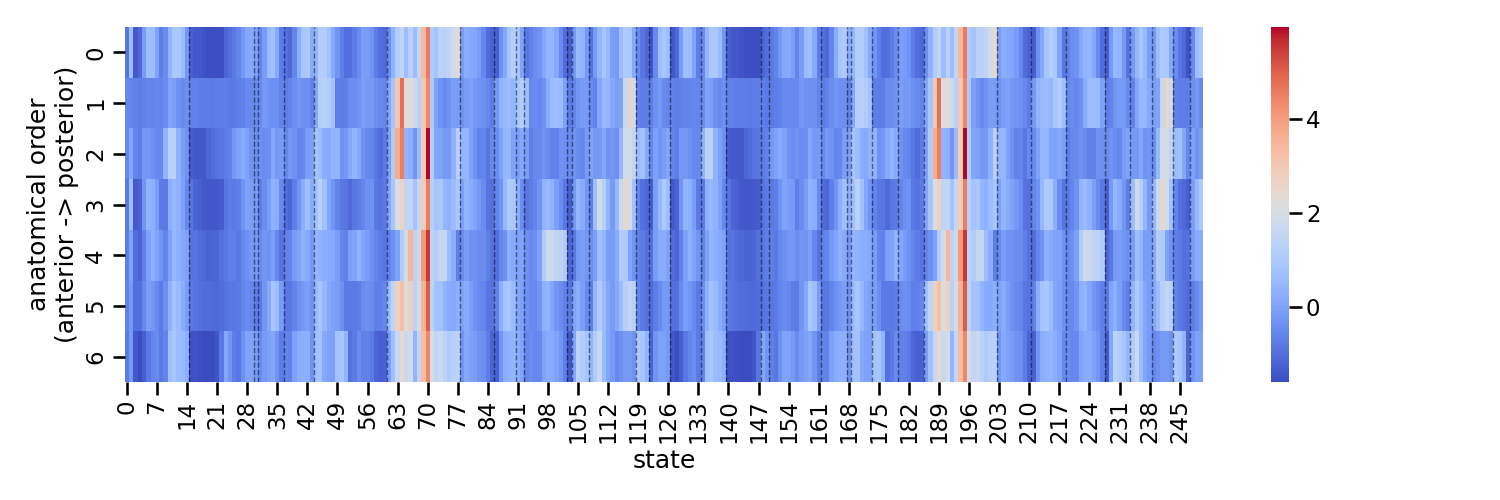

In [37]:
# plot the averaged emissions matrix by anatomical order
B_anatomical_averaged_normalized = stats.zscore(B_anatomical_averaged, axis=0)
plt.figure(figsize=(15, 5))
sns.heatmap(B_anatomical_averaged_normalized.T, cmap ='coolwarm')

# draw verical lines at the sequence boundaries
for bound in seq_bounds_forward:
    plt.axvline(x=bound + 1, color='k', linestyle='--', linewidth=1, alpha = 0.5)

for bound in seq_bounds_reverse:
    plt.axvline(x=bound + columns, color='k', linestyle='--', linewidth=1, alpha = 0.5)


plt.xlabel('state')
plt.ylabel('anatomical order\n(anterior -> posterior)')
plt.tight_layout()
plt.show()

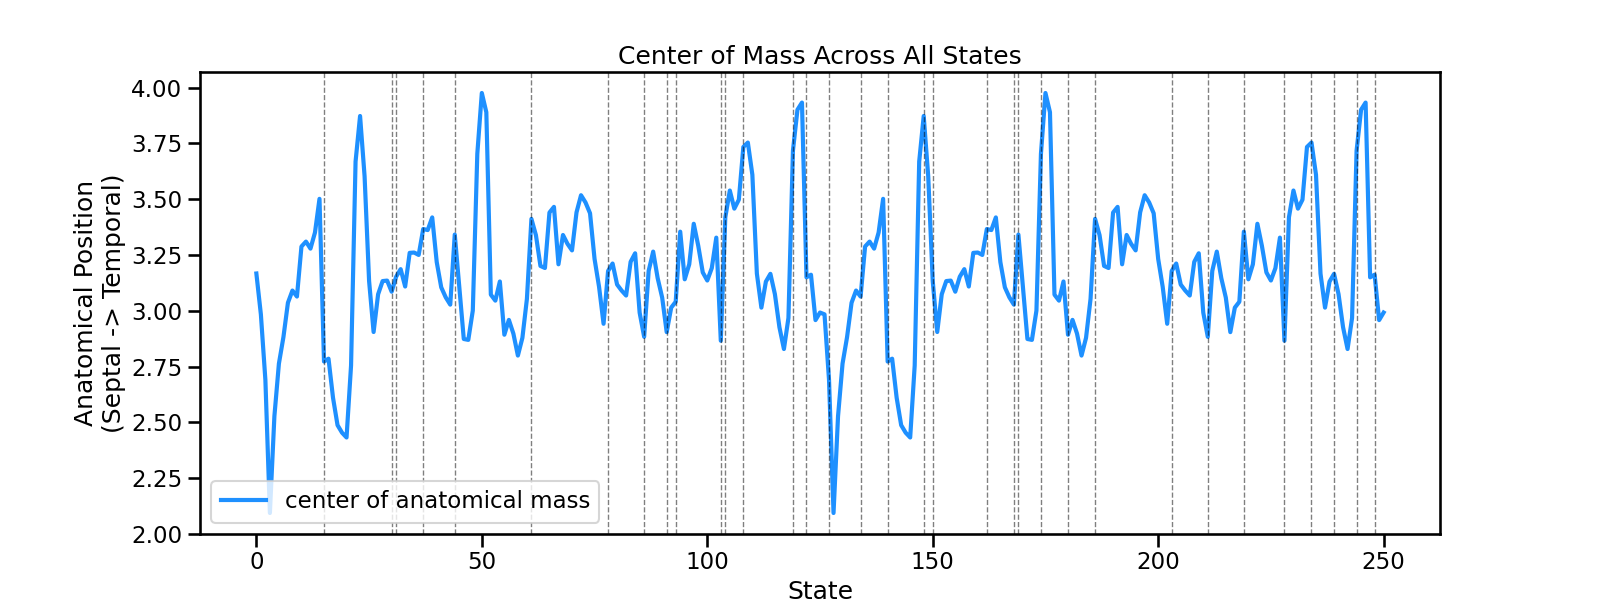

In [38]:
from scipy.stats import pearsonr



# average all the columns of B with the same anatomical_order value
B_anatomical_averaged = np.zeros((B.shape[0], len(np.unique(anatomical_order))))
for i, val in enumerate(np.unique(anatomical_order)):
    B_anatomical_averaged[:, i] = B[:, anatomical_order == val].mean(axis=1)

# make one long plot showing the center of mass across all the states
com = []
nStates = B_anatomical_averaged.shape[0]
for state in range(nStates):
    state_distribution = B_anatomical_averaged[state, :]
    state_distribution = state_distribution / np.sum(state_distribution)
    center_of_mass_position = np.sum(np.arange(len(state_distribution)) * state_distribution) / np.sum(state_distribution)
    com.append(center_of_mass_position)
com = np.array(com)
plt.figure(figsize=(16, 6))
plt.plot(range(len(com)), com, label="center of anatomical mass", linewidth=3, color = 'dodgerblue')
# draw verical lines at the sequence boundaries
for bound in seq_bounds_forward:
    plt.axvline(x=bound + 1, color='k', linestyle='--', linewidth=1, alpha = 0.5)

for bound in seq_bounds_reverse:
    plt.axvline(x=bound + columns, color='k', linestyle='--', linewidth=1, alpha = 0.5)

plt.title("Center of Mass Across All States")
plt.xlabel("State")
plt.ylabel("Anatomical Position\n(Septal -> Temporal)")
plt.legend()
plt.show()


 


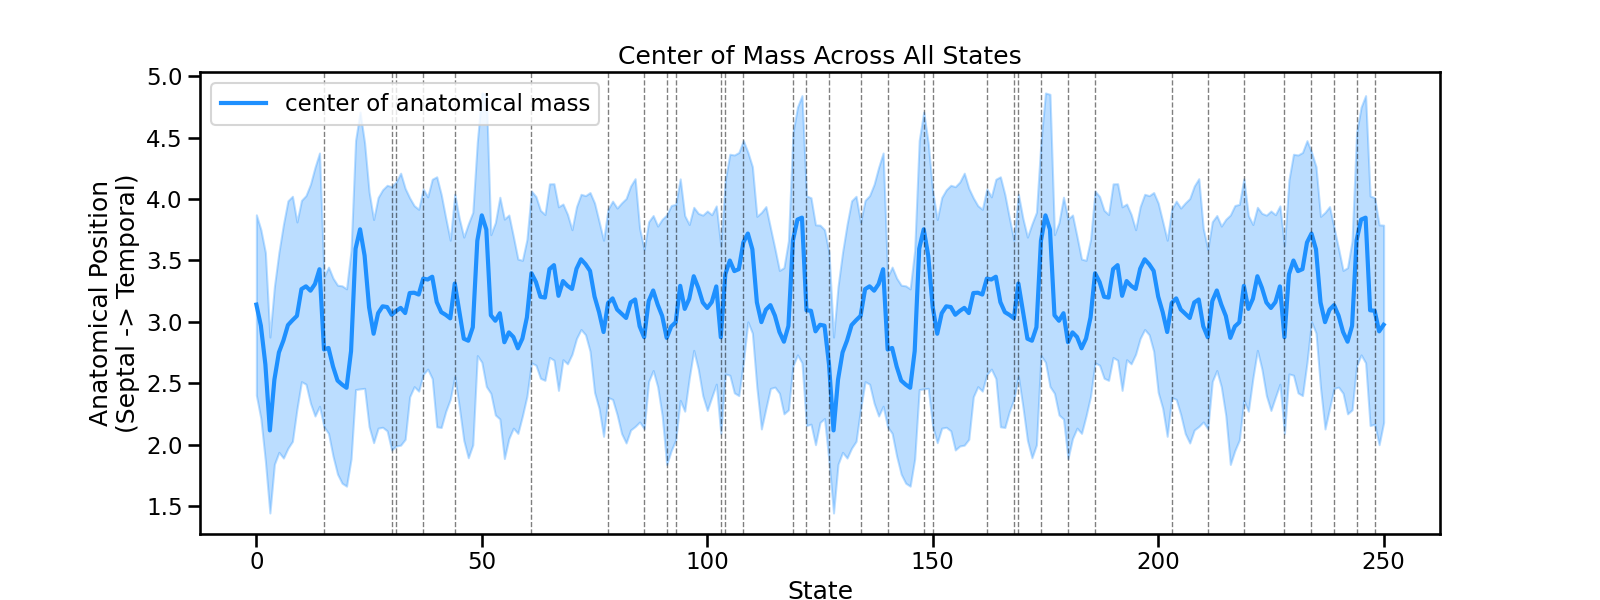

In [39]:
#### BOOTSTRAP to get CI on the center of anatomical mass


from scipy.stats import pearsonr

Niters = 1000
all_com = []
unique_positions = np.unique(anatomical_order)

for _ in range(Niters):
    B_anatomical_averaged_bootstrap = np.zeros((B.shape[0], len(unique_positions)))
    for i, val in enumerate(unique_positions):
        unit_idx = np.where(anatomical_order == val)[0]
        resampled_idx = np.random.choice(unit_idx, size=len(unit_idx), replace=True)
        B_anatomical_averaged_bootstrap[:, i] = B[:, resampled_idx].mean(axis=1)

    com = []
    nStates = B_anatomical_averaged_bootstrap.shape[0]
    for state in range(nStates):
        state_distribution = B_anatomical_averaged_bootstrap[state, :]
        state_distribution = state_distribution / np.sum(state_distribution)
        com.append(np.sum(np.arange(len(state_distribution)) * state_distribution))
    all_com.append(np.array(com))

mean_com = np.mean(all_com, axis=0)
lower_com = np.percentile(all_com, 2.5, axis=0)
upper_com = np.percentile(all_com, 97.5, axis=0)

plt.figure(figsize=(16, 6))
plt.plot(range(len(mean_com)), mean_com, label="center of anatomical mass", linewidth=3, color = 'dodgerblue')
plt.fill_between(range(len(mean_com)), lower_com, upper_com, color='dodgerblue', alpha=0.3)
# draw verical lines at the sequence boundaries
for bound in seq_bounds_forward:
    plt.axvline(x=bound + 1, color='k', linestyle='--', linewidth=1, alpha = 0.5)

for bound in seq_bounds_reverse:
    plt.axvline(x=bound + columns, color='k', linestyle='--', linewidth=1, alpha = 0.5)

plt.title("Center of Mass Across All States")
plt.xlabel("State")
plt.ylabel("Anatomical Position\n(Septal -> Temporal)")
plt.legend()
plt.show()

## Statistical test of anatomical propogation 

[(np.int64(0), np.int64(14)), (np.int64(14), np.int64(29)), (np.int64(29), np.int64(30)), (np.int64(30), np.int64(36)), (np.int64(36), np.int64(43)), (np.int64(43), np.int64(60)), (np.int64(60), np.int64(77)), (np.int64(77), np.int64(85)), (np.int64(85), np.int64(90)), (np.int64(90), np.int64(92)), (np.int64(92), np.int64(102)), (np.int64(102), np.int64(103)), (np.int64(103), np.int64(107)), (np.int64(107), np.int64(118)), (np.int64(118), np.int64(121)), (np.int64(121), np.int64(125)), (np.int64(125), np.int64(127)), (np.int64(127), np.int64(134)), (np.int64(134), np.int64(140)), (np.int64(140), np.int64(148)), (np.int64(148), np.int64(150)), (np.int64(150), np.int64(162)), (np.int64(162), np.int64(168)), (np.int64(168), np.int64(169)), (np.int64(169), np.int64(174)), (np.int64(174), np.int64(180)), (np.int64(180), np.int64(186)), (np.int64(186), np.int64(203)), (np.int64(203), np.int64(211)), (np.int64(211), np.int64(219)), (np.int64(219), np.int64(228)), (np.int64(228), np.int64(234)

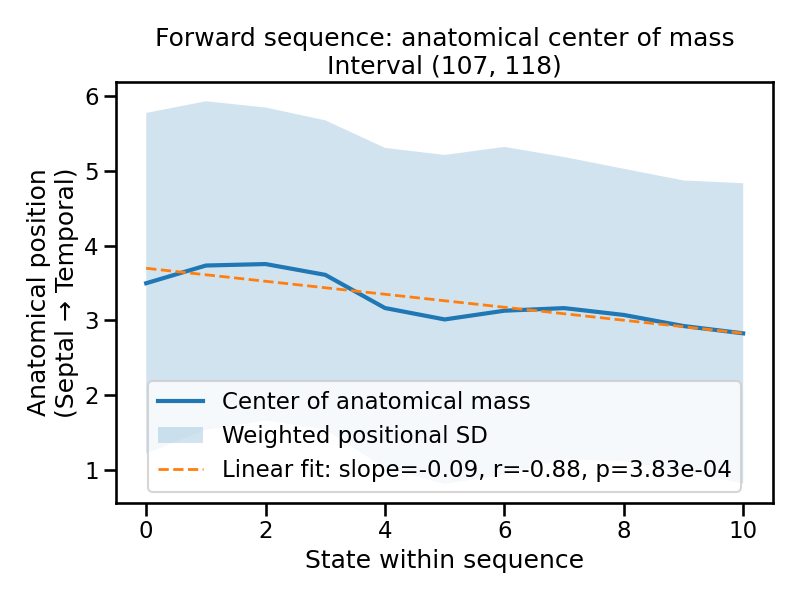

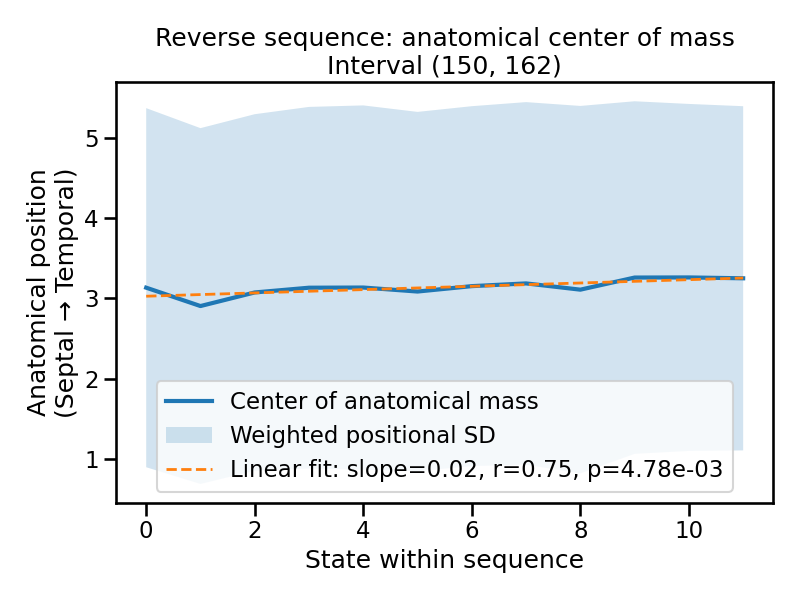

In [40]:
# Ensure boundary arrays are one-dimensional integer arrays
seq_bounds_forward = np.asarray(seq_bounds_forward, dtype=int).ravel()
seq_bounds_reverse = np.asarray(seq_bounds_reverse, dtype=int).ravel()

# Recompute the true (unresampled) anatomically-averaged emissions matrix, since
# the bootstrap CI cell above only ever writes to B_anatomical_averaged_bootstrap now.
B_anatomical_averaged = np.zeros((B.shape[0], len(np.unique(anatomical_order))))
for i, val in enumerate(np.unique(anatomical_order)):
    B_anatomical_averaged[:, i] = B[:, anatomical_order == val].mean(axis=1)

n_states = B_anatomical_averaged.shape[0]

# Construct boundaries for the two halves of the state space.
# Forward states occupy [0, 125), and reverse states occupy [125, 250).
forward_boundaries = np.unique(
    np.concatenate(([0], seq_bounds_forward, [125]))
)

reverse_boundaries = np.unique(
    np.concatenate(([125], seq_bounds_reverse + 125, [n_states]))
)

# Convert consecutive boundaries into intervals
forward_intervals = list(zip(
    forward_boundaries[:-1],
    forward_boundaries[1:]
))

reverse_intervals = list(zip(
    reverse_boundaries[:-1],
    reverse_boundaries[1:]
))

intervals = forward_intervals + reverse_intervals

print(intervals)

all_r = np.zeros((Niters, len(intervals)))
all_slopes = np.zeros((Niters, len(intervals)))
all_p = np.zeros((Niters, len(intervals)))
for iter in range(Niters):

    for interval_index, (start, stop) in enumerate(intervals):
        current_interval = (int(start), int(stop))

        # Skip invalid or empty intervals
        if stop <= start:
            continue

        interval_emissions_matrix = B_anatomical_averaged[start:stop, :]
        n_states_in_interval = interval_emissions_matrix.shape[0]

        if iter == 0 or n_states_in_interval < 2:
            # true data (or an interval too short to meaningfully shift)
            current_emissions_matrix = interval_emissions_matrix
        else:
            # Null distribution: circularly shift *which state's tuning curve
            # occupies which position in the interval's state-ordered sequence*.
            # This preserves each state's real anatomical tuning curve (and the
            # local state-to-state autocorrelation structure) while breaking the
            # pairing between "position in the sequence" and "anatomical COM"
            # that the test is actually assessing.
            shift_amount = np.random.randint(1, n_states_in_interval)
            current_emissions_matrix = np.roll(interval_emissions_matrix, shift_amount, axis=0)

        com = []
        positional_rmse = []

        anatomical_positions = np.arange(
            current_emissions_matrix.shape[1],
            dtype=float
        )

        for state_distribution in current_emissions_matrix:
            total_mass = np.sum(state_distribution)

            # Handle states with no valid probability mass
            if not np.isfinite(total_mass) or total_mass <= 0:
                com.append(np.nan)
                positional_rmse.append(np.nan)
                continue

            # Normalize into a valid probability mass function
            probability_mass = state_distribution / total_mass

            center_of_mass_position = np.sum(
                anatomical_positions * probability_mass
            )

            # Probability-weighted positional variance
            positional_variance = np.sum(
                probability_mass
                * (anatomical_positions - center_of_mass_position) ** 2
            )

            com.append(center_of_mass_position)
            positional_rmse.append(np.sqrt(positional_variance))

        com = np.asarray(com)
        positional_rmse = np.asarray(positional_rmse)

        state_indices = np.arange(len(com))

        # Remove states for which the COM could not be computed
        valid = np.isfinite(com)

        if valid.sum() < 3:
            continue

        valid_states = state_indices[valid]
        valid_com = com[valid]
        valid_rmse = positional_rmse[valid]

        r, p = pearsonr(valid_states, valid_com)
        slope, intercept = np.polyfit(valid_states, valid_com, deg=1)

        fitted_com = slope * valid_states + intercept

        all_r[iter, interval_index] = r
        all_slopes[iter, interval_index] = slope
        all_p[iter, interval_index] = p
        if p < 0.01 and iter == 0:

            plt.figure(figsize=(8, 6))

            plt.plot(
                valid_states,
                valid_com,
                linewidth=3,
                label="Center of anatomical mass",
            )

            plt.fill_between(
                valid_states,
                valid_com - valid_rmse,
                valid_com + valid_rmse,
                alpha=0.2,
                label="Weighted positional SD",
            )

            plt.plot(
                valid_states,
                fitted_com,
                linestyle="--",
                linewidth=2,
                label=(
                    f"Linear fit: slope={slope:.2f}, "
                    f"r={r:.2f}, p={p:.2e}"
                ),
            )

            direction = (
                "Forward"
                if current_interval[0] < 125
                else "Reverse"
            )

            plt.title(
                f"{direction} sequence: anatomical center of mass\n"
                f"Interval {current_interval}"
            )
            plt.xlabel("State within sequence")
            plt.ylabel("Anatomical position\n(Septal → Temporal)")
            plt.legend()
            plt.tight_layout()
            plt.show()

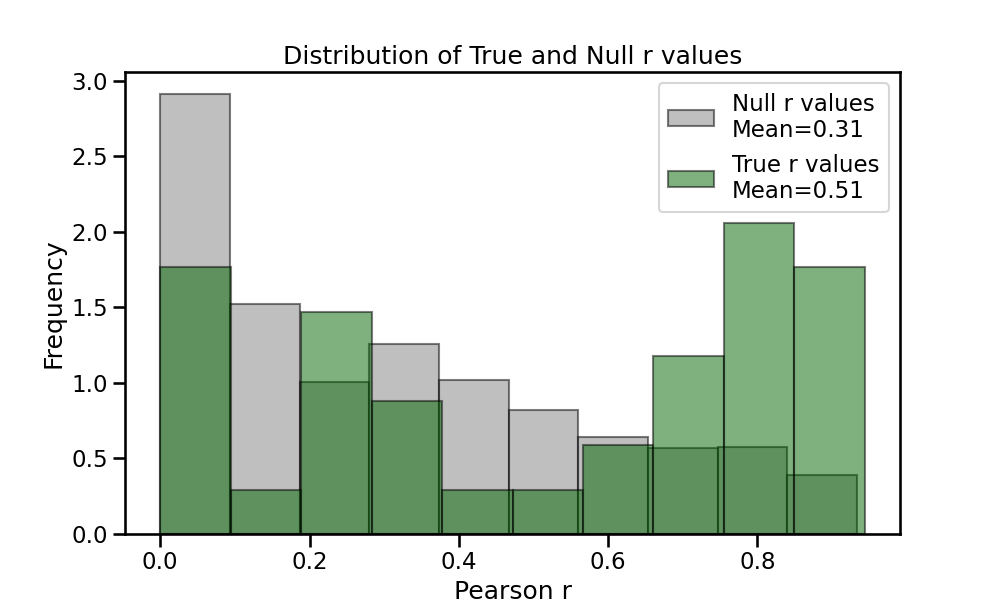

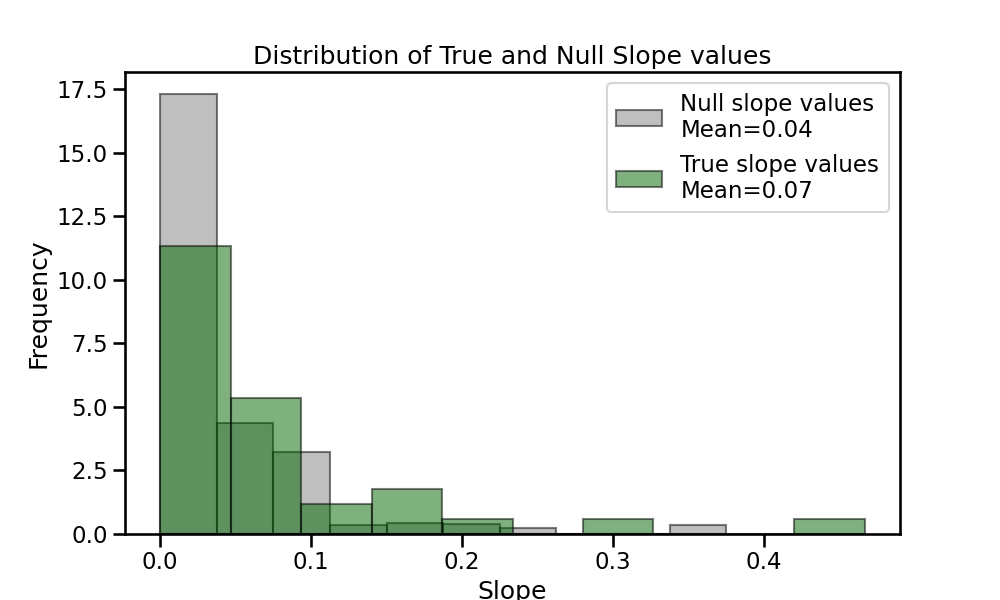

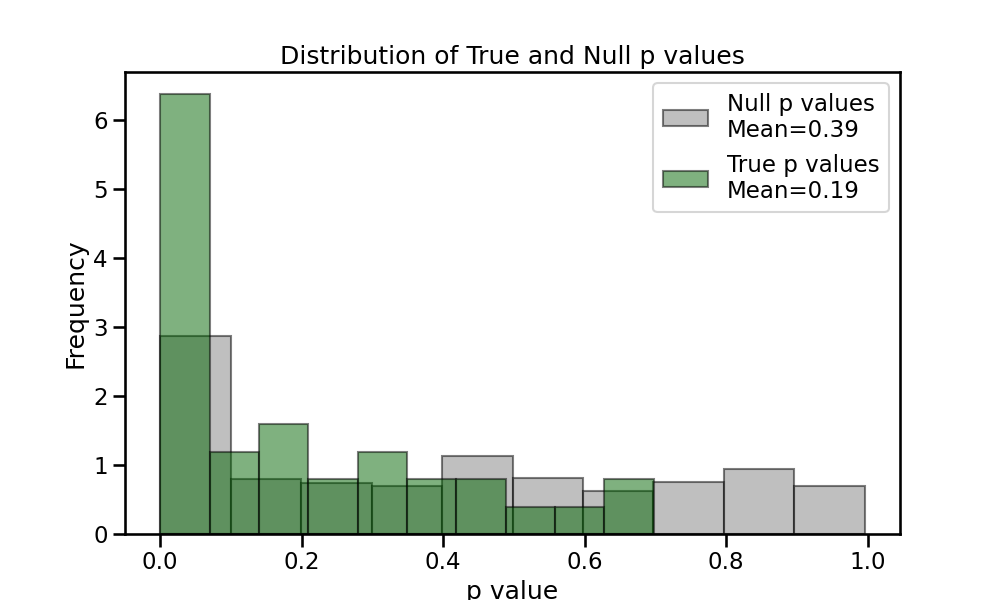

In [41]:
# plot the distribution of true r and the null r values
true_r = all_r[0, :]
null_r = all_r[1:, :].ravel()

plt.figure(figsize=(10, 6))
plt.hist(np.abs(null_r), bins=10, alpha=0.5, label=f"Null r values\nMean={np.mean(np.abs(null_r)):.2f}", density=True, edgecolor='black', color = 'grey')
plt.hist(np.abs(true_r), bins=10, alpha=0.5, label=f"True r values\nMean={np.mean(np.abs(true_r)):.2f}", density=True, edgecolor='black', color = 'darkgreen')
plt.xlabel("Pearson r")
plt.ylabel("Frequency")
plt.title("Distribution of True and Null r values")
plt.legend()
plt.show()

# plot the distribution of true and null slope values
true_slope = all_slopes[0, :]
null_slope = all_slopes[1:, :].ravel()

plt.figure(figsize=(10, 6))
plt.hist(np.abs(null_slope), bins=10, alpha=0.5, label=f"Null slope values\nMean={np.mean(np.abs(null_slope)):.2f}", density=True, edgecolor='black', color = 'grey')
plt.hist(np.abs(true_slope), bins=10, alpha=0.5, label=f"True slope values\nMean={np.mean(np.abs(true_slope)):.2f}", density=True, edgecolor='black', color = 'darkgreen')
plt.xlabel("Slope")
plt.ylabel("Frequency")
plt.title("Distribution of True and Null Slope values")
plt.legend()
plt.show()

# plot the distribution of true and null p values
true_p = all_p[0, :]
null_p = all_p[1:, :].ravel()

plt.figure(figsize=(10, 6))
plt.hist(null_p, bins=10, alpha=0.5, label=f"Null p values\nMean={np.mean(null_p):.2f}", density=True, edgecolor='black', color = 'grey')
plt.hist(true_p, bins=10, alpha=0.5, label=f"True p values\nMean={np.mean(true_p):.2f}", density=True, edgecolor='black', color = 'darkgreen')
plt.xlabel("p value")
plt.ylabel("Frequency")
plt.title("Distribution of True and Null p values")
plt.legend()
plt.show()